# TrashNet — MobileNetV3Small con y sin Optuna (PyTorch)

Réplica en **PyTorch** del notebook `tensorflow/TrashNet_TensorFlow_MobileNetV3_DEFINITIVO.ipynb`.
Mismo dataset, mismo backbone, mismo protocolo experimental y las mismas métricas, para que la
comparación entre frameworks sea justa.

El flujo es idéntico al de TensorFlow:

1. Importación y revisión del dataset.
2. Modelo base con hiperparámetros definidos manualmente.
3. Entrenamiento en dos fases:
   - **Fase 1:** transferencia de aprendizaje con MobileNetV3 congelada.
   - **Fase 2:** *fine-tuning* de las últimas capas.
4. Optimización automática de hiperparámetros con **Optuna**.
5. Entrenamiento final del modelo optimizado.
6. Comparación completa entre ambos modelos:
   - accuracy, precision, recall y F1;
   - curvas de entrenamiento;
   - matrices de confusión;
   - reportes de clasificación;
   - curvas ROC y AUC;
   - resumen final comparativo.

> El conjunto de test se utiliza únicamente al final para comparar los modelos terminados.

---

### Diferencias respecto al notebook de TensorFlow (y por qué)

Todas son consecuencia del framework o del entorno, no del diseño experimental:

| Tema | TensorFlow | Aquí (PyTorch) | Motivo |
|---|---|---|---|
| Métricas | `sklearn.metrics` | implementadas a mano con NumPy | el env `frameworks-ia` **no tiene scikit-learn** (ver `CONTEXT.md` §5) |
| Tablas | `pandas.DataFrame` | impresión formateada | pandas tampoco está instalado |
| Aumento de datos | capas `RandomFlip/Rotation/...` dentro del modelo | `torchvision.transforms` en el `Dataset` de train | en PyTorch el aumento vive en el pipeline de datos; el efecto es el mismo (solo se aplica en train) |
| Preprocesado | `include_preprocessing=True` dentro del backbone | `Normalize(mean, std)` de ImageNet | así se pide en `torchvision` |
| Fine-tuning | "últimas 20 capas" de Keras | **últimos 3 bloques** de `features` | 20 capas Keras ≈ los 3 últimos bloques invertidos de `torchvision`; la granularidad no es la misma |
| BatchNorm | `layer.trainable = False` (⇒ modo inferencia) | `model.features.eval()` durante el entrenamiento | replica exactamente el comportamiento de Keras |

**Antes de ejecutar** necesitas `optuna` en el entorno:

```bash
conda activate frameworks-ia
pip install optuna
```

In [1]:
import sys; print(sys.executable)

/home/benjamin-sanchez/miniconda3/envs/frameworks-ia/bin/python


In [2]:
# 1. Importaciones y configuración general

import os
import gc
import copy
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_FASE1 = 25
EPOCHS_FASE2 = 15

# Búsqueda rápida de Optuna
OPTUNA_TRIALS = 10
OPTUNA_EPOCHS = 8

# 0 evita problemas con el multiprocessing dentro de Jupyter; súbelo a 2-4 si va lento
NUM_WORKERS = 0

BASE_DIR = "../dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
N_CLASSES = len(CLASSES)

# Normalización estándar de ImageNet, la que espera el backbone preentrenado
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Los pesos del notebook van a modelos/ y las figuras a predicciones/, siguiendo la
# convención de PyTorch/CONTEXT.md (resultados/ es la salida de los scripts).
MODEL_DIR = "modelos"
RESULTS_DIR = "predicciones"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Optuna:", optuna.__version__)
print("Dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    print("GPU detectada: No; se utilizará CPU (el entrenamiento será lento)")

PyTorch: 2.12.1+cpu
Optuna: 4.9.0
Dispositivo: cpu
GPU detectada: No; se utilizará CPU (el entrenamiento será lento)


In [3]:
# 2. Validación de la estructura del dataset

def validar_directorio_dataset(ruta, nombre):
    if not os.path.isdir(ruta):
        raise FileNotFoundError(
            f"No existe el directorio {nombre}: {ruta}"
        )

    clases_encontradas = sorted(
        carpeta for carpeta in os.listdir(ruta)
        if os.path.isdir(os.path.join(ruta, carpeta))
    )

    faltantes = sorted(set(CLASSES) - set(clases_encontradas))
    if faltantes:
        raise ValueError(
            f"Faltan clases en {nombre}: {faltantes}"
        )

    print(f"{nombre}: {clases_encontradas}")

validar_directorio_dataset(TRAIN_DIR, "Train")
validar_directorio_dataset(VALID_DIR, "Validation")
validar_directorio_dataset(TEST_DIR, "Test")

Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Validation: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [4]:
# 3. Conteo de imágenes por clase
#    (sin pandas: se imprime la tabla a mano)

def contar_imagenes_por_clase(ruta):
    extensiones = (".jpg", ".jpeg", ".png", ".webp")
    conteo = {}

    for clase in CLASSES:
        carpeta = os.path.join(ruta, clase)
        conteo[clase] = sum(
            archivo.lower().endswith(extensiones)
            for archivo in os.listdir(carpeta)
        )

    return conteo

train_count = contar_imagenes_por_clase(TRAIN_DIR)
valid_count = contar_imagenes_por_clase(VALID_DIR)
test_count = contar_imagenes_por_clase(TEST_DIR)

print(f"{'clase':<12}{'train':>8}{'validation':>13}{'test':>8}")
for clase in CLASSES:
    print(
        f"{clase:<12}"
        f"{train_count[clase]:>8}"
        f"{valid_count[clase]:>13}"
        f"{test_count[clase]:>8}"
    )

print("\nTotales:")
print(
    f"{'':<12}"
    f"{sum(train_count.values()):>8}"
    f"{sum(valid_count.values()):>13}"
    f"{sum(test_count.values()):>8}"
)

clase          train   validation    test
cardboard        282           60      61
glass            350           75      76
metal            287           61      62
paper            415           89      90
plastic          337           72      73
trash             95           20      22

Totales:
                1766          377     384


In [5]:
# 4. Pesos de clase para compensar el desbalance
#    Misma fórmula que sklearn compute_class_weight("balanced"):
#    peso_i = n_muestras / (n_clases * conteo_i)

conteos = np.array(
    [train_count[clase] for clase in CLASSES],
    dtype=np.float64
)

class_weights_array = conteos.sum() / (N_CLASSES * conteos)

class_weights = {
    indice: float(peso)
    for indice, peso in enumerate(class_weights_array)
}

# En PyTorch los pesos se pasan como tensor a CrossEntropyLoss
class_weights_tensor = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
    device=DEVICE
)

print("Pesos por clase:")
for indice, peso in class_weights.items():
    print(f"{indice} - {CLASSES[indice]:10s}: {peso:.4f}")

Pesos por clase:
0 - cardboard : 1.0437
1 - glass     : 0.8410
2 - metal     : 1.0256
3 - paper     : 0.7092
4 - plastic   : 0.8734
5 - trash     : 3.0982


In [6]:
# 5. Data augmentation
#    Equivalente a las capas RandomFlip/RandomRotation/RandomZoom/RandomContrast/
#    RandomTranslation del notebook de TensorFlow. En PyTorch el aumento vive en el
#    pipeline de datos, así que solo se aplica al Dataset de entrenamiento.

def crear_data_augmentation():
    return [
        transforms.RandomHorizontalFlip(),                 # RandomFlip("horizontal")
        transforms.RandomRotation(degrees=36),             # RandomRotation(0.10) -> 0.10 * 360°
        transforms.RandomAffine(                           # RandomZoom(0.10) + RandomTranslation(0.05)
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.90, 1.10)
        ),
        transforms.ColorJitter(contrast=0.10),             # RandomContrast(0.10)
    ]

normalizacion = [
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
]

train_tf = transforms.Compose(
    [transforms.Resize(IMG_SIZE), *crear_data_augmentation(), *normalizacion]
)

eval_tf = transforms.Compose(
    [transforms.Resize(IMG_SIZE), *normalizacion]
)

In [7]:
# 6. Importación del dataset
#    ImageFolder ordena las clases alfabéticamente, que es exactamente el orden de
#    CLASSES; se comprueba abajo para no depender de esa suposición.

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=eval_tf)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tf)

assert train_ds.classes == CLASSES, (
    f"Orden de clases inesperado: {train_ds.classes}"
)

generador = torch.Generator()
generador.manual_seed(SEED)

comun = dict(
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=NUM_WORKERS > 0
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generador,
    **comun
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **comun
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **comun
)

print("Clases:", CLASSES)
print(f"Train: {len(train_ds)} | Validation: {len(valid_ds)} | Test: {len(test_ds)}")

Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train: 1766 | Validation: 377 | Test: 384


## Parte A — Modelo sin Optuna

En esta versión los hiperparámetros se definen manualmente:

- capa densa: 128 neuronas;
- dropout: 0,35;
- optimizador: Adam;
- learning rate de fase 1: 3e-4;
- fine-tuning: últimos 3 bloques del backbone con learning rate 1e-5.

In [8]:
# 7. Constructor general de MobileNetV3Small

class TrashNetMobileNetV3(nn.Module):
    """
    Réplica del modelo de Keras:
        MobileNetV3Small(include_top=False) -> GlobalAveragePooling2D
        -> Dense(dense_units, relu) -> Dropout -> Dense(N_CLASSES, softmax)

    La softmax NO va en el modelo: CrossEntropyLoss la aplica internamente sobre los
    logits. Para obtener probabilidades se usa torch.softmax en la evaluación.
    """

    def __init__(self, dense_units, dropout_rate, n_classes=N_CLASSES):
        super().__init__()

        base = mobilenet_v3_small(
            weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        self.features = base.features                    # backbone preentrenado
        n_features = base.classifier[0].in_features       # 576 en MobileNetV3Small

        self.pool = nn.AdaptiveAvgPool2d(1)               # GlobalAveragePooling2D
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, dense_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(dense_units, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)


def congelar_backbone(model):
    """Fase 1: el backbone completo queda congelado."""
    for parametro in model.features.parameters():
        parametro.requires_grad = False


def descongelar_ultimos_bloques(model, n_bloques=3):
    """
    Fase 2: se descongelan solo los últimos bloques del backbone.

    En Keras eran "las últimas 20 capas"; en torchvision el backbone está agrupado en
    13 bloques (`features[0..12]`), así que el equivalente razonable son los 3 últimos.
    Las BatchNorm quedan congeladas, igual que en el notebook de TensorFlow.
    """
    for parametro in model.features.parameters():
        parametro.requires_grad = False

    for bloque in model.features[-n_bloques:]:
        for parametro in bloque.parameters():
            parametro.requires_grad = True

    for modulo in model.features.modules():
        if isinstance(modulo, nn.BatchNorm2d):
            for parametro in modulo.parameters():
                parametro.requires_grad = False


def construir_optimizador(model, optimizer_name, learning_rate):
    entrenables = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name.lower() == "adam":
        return torch.optim.Adam(entrenables, lr=learning_rate)
    if optimizer_name.lower() == "rmsprop":
        return torch.optim.RMSprop(entrenables, lr=learning_rate)

    raise ValueError(f"Optimizador no soportado: {optimizer_name}")


def construir_modelo(
    dense_units,
    dropout_rate,
    optimizer_name,
    learning_rate,
    nombre_modelo
):
    model = TrashNetMobileNetV3(dense_units, dropout_rate).to(DEVICE)
    model.nombre = nombre_modelo

    # Fase 1: backbone congelado
    congelar_backbone(model)

    optimizer = construir_optimizador(model, optimizer_name, learning_rate)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    return model, optimizer, criterion


def resumen_modelo(model):
    total = sum(p.numel() for p in model.parameters())
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Modelo: {getattr(model, 'nombre', model.__class__.__name__)}")
    print(f"Parámetros totales:     {total:,}")
    print(f"Parámetros entrenables: {entrenables:,}")
    print(f"Parámetros congelados:  {total - entrenables:,}")

In [9]:
# 7b. Bucle de entrenamiento
#     Reproduce a mano lo que Keras hace con model.fit + EarlyStopping +
#     ReduceLROnPlateau, porque PyTorch no trae callbacks.

def limpiar_memoria():
    """Equivalente a keras.backend.clear_session() + gc.collect()."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def correr_epoca(model, loader, criterion, optimizer=None):
    """Una época. Si optimizer es None, solo evalúa. Devuelve (loss, accuracy)."""
    entrenando = optimizer is not None
    model.train(entrenando)

    # El backbone siempre en modo inferencia: replica el training=False de Keras y
    # deja las BatchNorm con sus estadísticas de ImageNet, tanto en fase 1 como en 2.
    model.features.eval()

    perdida_total = 0.0
    aciertos = 0
    total = 0

    with torch.set_grad_enabled(entrenando):
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if entrenando:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            perdida_total += loss.item() * labels.size(0)
            aciertos += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return perdida_total / total, aciertos / total


def entrenar(
    model,
    optimizer,
    criterion,
    epochs,
    patience_es,
    patience_lr,
    min_lr,
    verbose=1
):
    """
    Devuelve un history con las mismas claves que Keras:
    accuracy, val_accuracy, loss, val_loss.

    - EarlyStopping(monitor="val_accuracy", mode="max", restore_best_weights=True)
    - ReduceLROnPlateau(monitor="val_loss", factor=0.5)
    """
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=patience_lr,
        min_lr=min_lr
    )

    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

    mejor_val_acc = -np.inf
    mejores_pesos = copy.deepcopy(model.state_dict())
    epocas_sin_mejora = 0
    inicio = time.time()

    for epoca in range(epochs):
        lr_antes = optimizer.param_groups[0]["lr"]

        train_loss, train_acc = correr_epoca(model, train_loader, criterion, optimizer)
        val_loss, val_acc = correr_epoca(model, valid_loader, criterion)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        scheduler.step(val_loss)
        lr_despues = optimizer.param_groups[0]["lr"]

        if val_acc > mejor_val_acc:
            mejor_val_acc = val_acc
            mejores_pesos = copy.deepcopy(model.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        if verbose:
            print(
                f"Época {epoca + 1:02d}/{epochs} | "
                f"loss {train_loss:.4f} acc {train_acc:.4f} | "
                f"val_loss {val_loss:.4f} val_acc {val_acc:.4f} | "
                f"lr {lr_despues:.2e}"
            )
            if lr_despues < lr_antes:
                print(f"  ReduceLROnPlateau: learning rate {lr_antes:.2e} -> {lr_despues:.2e}")

        if epocas_sin_mejora >= patience_es:
            if verbose:
                print(
                    f"EarlyStopping en la época {epoca + 1}: "
                    f"{patience_es} épocas sin mejorar val_accuracy"
                )
            break

    model.load_state_dict(mejores_pesos)

    if verbose:
        print(
            f"Mejor val_accuracy: {mejor_val_acc:.4f} "
            f"(pesos restaurados) — {time.time() - inicio:.1f}s"
        )

    return history

In [10]:
# 8. Modelo base sin Optuna — Fase 1

limpiar_memoria()

BASE_DENSE_UNITS = 128
BASE_DROPOUT = 0.35
BASE_LR = 3e-4
BASE_OPTIMIZER = "adam"

model_base, optimizer_base, criterion = construir_modelo(
    dense_units=BASE_DENSE_UNITS,
    dropout_rate=BASE_DROPOUT,
    optimizer_name=BASE_OPTIMIZER,
    learning_rate=BASE_LR,
    nombre_modelo="trashnet_mobilenetv3_sin_optuna"
)

resumen_modelo(model_base)

Modelo: trashnet_mobilenetv3_sin_optuna
Parámetros totales:     1,001,638
Parámetros entrenables: 74,630
Parámetros congelados:  927,008


In [11]:
# 9. Entrenamiento del modelo base — Fase 1

history_base_fase1 = entrenar(
    model_base,
    optimizer_base,
    criterion,
    epochs=EPOCHS_FASE1,
    patience_es=6,
    patience_lr=3,
    min_lr=1e-6,
    verbose=1
)

Época 01/25 | loss 1.5348 acc 0.4875 | val_loss 1.2232 val_acc 0.6499 | lr 3.00e-04
Época 02/25 | loss 1.1266 acc 0.6410 | val_loss 0.9148 val_acc 0.7082 | lr 3.00e-04
Época 03/25 | loss 0.9177 acc 0.7067 | val_loss 0.7791 val_acc 0.7480 | lr 3.00e-04
Época 04/25 | loss 0.8123 acc 0.7378 | val_loss 0.6785 val_acc 0.7905 | lr 3.00e-04
Época 05/25 | loss 0.7277 acc 0.7571 | val_loss 0.6380 val_acc 0.7905 | lr 3.00e-04
Época 06/25 | loss 0.6653 acc 0.7684 | val_loss 0.6277 val_acc 0.7931 | lr 3.00e-04
Época 07/25 | loss 0.6158 acc 0.7933 | val_loss 0.5631 val_acc 0.8090 | lr 3.00e-04
Época 08/25 | loss 0.5880 acc 0.8109 | val_loss 0.5557 val_acc 0.8064 | lr 3.00e-04
Época 09/25 | loss 0.5571 acc 0.8097 | val_loss 0.5404 val_acc 0.8249 | lr 3.00e-04
Época 10/25 | loss 0.5457 acc 0.8126 | val_loss 0.5256 val_acc 0.8090 | lr 3.00e-04
Época 11/25 | loss 0.5123 acc 0.8267 | val_loss 0.5381 val_acc 0.8011 | lr 3.00e-04
Época 12/25 | loss 0.4873 acc 0.8364 | val_loss 0.5353 val_acc 0.8064 | lr 3

In [12]:
# 10. Modelo base — Fase 2: fine-tuning

descongelar_ultimos_bloques(model_base, n_bloques=3)
resumen_modelo(model_base)

# Learning rate reducido para ajustes pequeños sobre pesos preentrenados
optimizer_base_fase2 = construir_optimizador(model_base, "adam", 1e-5)

history_base_fase2 = entrenar(
    model_base,
    optimizer_base_fase2,
    criterion,
    epochs=EPOCHS_FASE2,
    patience_es=5,
    patience_lr=2,
    min_lr=1e-7,
    verbose=1
)

Modelo: trashnet_mobilenetv3_sin_optuna
Parámetros totales:     1,001,638
Parámetros entrenables: 713,126
Parámetros congelados:  288,512
Época 01/15 | loss 0.4182 acc 0.8652 | val_loss 0.4747 val_acc 0.8249 | lr 1.00e-05
Época 02/15 | loss 0.3757 acc 0.8783 | val_loss 0.4714 val_acc 0.8249 | lr 1.00e-05
Época 03/15 | loss 0.3688 acc 0.8794 | val_loss 0.4685 val_acc 0.8249 | lr 1.00e-05
Época 04/15 | loss 0.3671 acc 0.8794 | val_loss 0.4651 val_acc 0.8249 | lr 1.00e-05
Época 05/15 | loss 0.3586 acc 0.8771 | val_loss 0.4663 val_acc 0.8196 | lr 1.00e-05
Época 06/15 | loss 0.3525 acc 0.8834 | val_loss 0.4641 val_acc 0.8249 | lr 1.00e-05
EarlyStopping en la época 6: 5 épocas sin mejorar val_accuracy
Mejor val_accuracy: 0.8249 (pesos restaurados) — 238.6s


In [13]:
# 11. Guardar el modelo sin Optuna

RUTA_MODELO_BASE = os.path.join(
    MODEL_DIR,
    "trashnet_mobilenetv3_sin_optuna.pt"
)

torch.save(
    {
        "state_dict": model_base.state_dict(),
        "dense_units": BASE_DENSE_UNITS,
        "dropout_rate": BASE_DROPOUT,
        "classes": CLASSES,
        "img_size": IMG_SIZE
    },
    RUTA_MODELO_BASE
)

print("Modelo sin Optuna guardado en:", RUTA_MODELO_BASE)

Modelo sin Optuna guardado en: modelos/trashnet_mobilenetv3_sin_optuna.pt


## Parte B — Optimización con Optuna

Optuna probará automáticamente distintas combinaciones de:

- número de neuronas de la capa densa;
- dropout;
- learning rate;
- optimizador.

Cada combinación corresponde a un **trial**. El estudio maximiza la mejor accuracy de validación obtenida durante una búsqueda corta. Luego se reconstruye y entrena completamente el modelo ganador.

El espacio de búsqueda es exactamente el mismo que en el notebook de TensorFlow, para que la comparación entre frameworks tenga sentido.

In [14]:
# 12. Función objetivo para Optuna

def objective(trial):
    limpiar_memoria()

    dense_units = trial.suggest_categorical(
        "dense_units",
        [64, 128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.20,
        0.50,
        step=0.05
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop"]
    )

    model_trial, optimizer_trial, criterion_trial = construir_modelo(
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        nombre_modelo=f"trial_{trial.number}"
    )

    history_trial = entrenar(
        model_trial,
        optimizer_trial,
        criterion_trial,
        epochs=OPTUNA_EPOCHS,
        patience_es=3,
        patience_lr=2,
        min_lr=1e-7,
        verbose=0
    )

    best_val_accuracy = float(max(history_trial["val_accuracy"]))

    trial.set_user_attr(
        "epochs_executed",
        len(history_trial["accuracy"])
    )

    print(
        f"Trial {trial.number:02d} | "
        f"val_accuracy={best_val_accuracy:.4f} | "
        f"{trial.params}"
    )

    del model_trial, optimizer_trial
    limpiar_memoria()

    return best_val_accuracy

In [15]:
# 13. Ejecutar el estudio de Optuna

sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="TrashNet_MobileNetV3_Optuna_PyTorch"
)

study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS
)

print("\nMejor trial:", study.best_trial.number)
print(f"Mejor val_accuracy rápida: {study.best_value:.4f}")

print("\nMejores hiperparámetros:")
for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

[I 2026-08-06 08:15:19,246] A new study created in memory with name: TrashNet_MobileNetV3_Optuna_PyTorch
[I 2026-08-06 08:19:41,103] Trial 0 finished with value: 0.6525198938992043 and parameters: {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.6525198938992043.


Trial 00 | val_accuracy=0.6525 | {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}


[I 2026-08-06 08:23:54,581] Trial 1 finished with value: 0.843501326259947 and parameters: {'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0008706020878304854, 'optimizer': 'adam'}. Best is trial 1 with value: 0.843501326259947.


Trial 01 | val_accuracy=0.8435 | {'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0008706020878304854, 'optimizer': 'adam'}


[I 2026-08-06 08:28:14,833] Trial 2 finished with value: 0.7904509283819628 and parameters: {'dense_units': 256, 'dropout_rate': 0.35000000000000003, 'learning_rate': 7.309539835912905e-05, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.843501326259947.


...

Trial 07 | val_accuracy=0.8223 | {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0006161049539380963, 'optimizer': 'rmsprop'}


[I 2026-08-06 08:51:49,844] Trial 8 finished with value: 0.7480106100795756 and parameters: {'dense_units': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 5.989003672254293e-05, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.843501326259947.


Trial 08 | val_accuracy=0.7480 | {'dense_units': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 5.989003672254293e-05, 'optimizer': 'rmsprop'}


[I 2026-08-06 08:55:25,686] Trial 9 finished with value: 0.8381962864721485 and parameters: {'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0004021554526690286, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.843501326259947.


Trial 09 | val_accuracy=0.8382 | {'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0004021554526690286, 'optimizer': 'rmsprop'}

Mejor trial: 1
Mejor val_accuracy rápida: 0.8435

Mejores hiperparámetros:
dense_units: 64
dropout_rate: 0.2
learning_rate: 0.0008706020878304854
optimizer: adam


In [16]:
# 14. Tabla de todos los trials (sin pandas)

filas = sorted(
    study.trials,
    key=lambda t: (t.value if t.value is not None else -np.inf),
    reverse=True
)

encabezado = (
    f"{'number':>7}{'value':>10}{'dense_units':>13}"
    f"{'dropout':>10}{'learning_rate':>16}{'optimizer':>12}{'state':>12}"
)
print(encabezado)
print("-" * len(encabezado))

for trial in filas:
    valor = f"{trial.value:.4f}" if trial.value is not None else "-"
    print(
        f"{trial.number:>7}{valor:>10}"
        f"{trial.params.get('dense_units', '-'):>13}"
        f"{trial.params.get('dropout_rate', float('nan')):>10.2f}"
        f"{trial.params.get('learning_rate', float('nan')):>16.8f}"
        f"{trial.params.get('optimizer', '-'):>12}"
        f"{trial.state.name:>12}"
    )

 number     value  dense_units   dropout   learning_rate   optimizer       state
--------------------------------------------------------------------------------
      1    0.8435           64      0.20      0.00087060        adam    COMPLETE
      3    0.8382          256      0.35      0.00037184     rmsprop    COMPLETE
      9    0.8382          256      0.20      0.00040216     rmsprop    COMPLETE
      7    0.8223          128      0.50      0.00061610     rmsprop    COMPLETE
      2    0.7905          256      0.35      0.00007310     rmsprop    COMPLETE
      8    0.7480          128      0.30      0.00005989     rmsprop    COMPLETE
      6    0.7215          128      0.40      0.00004202     rmsprop    COMPLETE
      5    0.7082           64      0.40      0.00007591     rmsprop    COMPLETE
      4    0.6870          256      0.25      0.00001349     rmsprop    COMPLETE
      0    0.6525          128      0.40      0.00002051        adam    COMPLETE


In [17]:
# 15. Crear modelo final con los parámetros ganadores

best_params = study.best_params

BEST_DENSE_UNITS = best_params["dense_units"]
BEST_DROPOUT = best_params["dropout_rate"]
BEST_LR = best_params["learning_rate"]
BEST_OPTIMIZER = best_params["optimizer"]

limpiar_memoria()

model_optuna, optimizer_optuna, criterion = construir_modelo(
    dense_units=BEST_DENSE_UNITS,
    dropout_rate=BEST_DROPOUT,
    optimizer_name=BEST_OPTIMIZER,
    learning_rate=BEST_LR,
    nombre_modelo="trashnet_mobilenetv3_optuna"
)

print("Configuración ganadora:")
print("Dense units:", BEST_DENSE_UNITS)
print("Dropout:", BEST_DROPOUT)
print("Learning rate:", BEST_LR)
print("Optimizer:", BEST_OPTIMIZER)
print()

resumen_modelo(model_optuna)

Configuración ganadora:
Dense units: 64
Dropout: 0.2
Learning rate: 0.0008706020878304854
Optimizer: adam

Modelo: trashnet_mobilenetv3_optuna
Parámetros totales:     964,326
Parámetros entrenables: 37,318
Parámetros congelados:  927,008


In [18]:
# 16. Modelo Optuna — Fase 1

history_optuna_fase1 = entrenar(
    model_optuna,
    optimizer_optuna,
    criterion,
    epochs=EPOCHS_FASE1,
    patience_es=6,
    patience_lr=3,
    min_lr=1e-7,
    verbose=1
)

Época 01/25 | loss 1.3242 acc 0.5527 | val_loss 0.8576 val_acc 0.7294 | lr 8.71e-04
Época 02/25 | loss 0.8769 acc 0.6971 | val_loss 0.7384 val_acc 0.7560 | lr 8.71e-04
Época 03/25 | loss 0.6971 acc 0.7616 | val_loss 0.5969 val_acc 0.7984 | lr 8.71e-04
Época 04/25 | loss 0.6293 acc 0.7877 | val_loss 0.5662 val_acc 0.8117 | lr 8.71e-04
Época 05/25 | loss 0.5770 acc 0.8126 | val_loss 0.5683 val_acc 0.8170 | lr 8.71e-04
Época 06/25 | loss 0.5347 acc 0.8182 | val_loss 0.5540 val_acc 0.8011 | lr 8.71e-04
Época 07/25 | loss 0.4811 acc 0.8454 | val_loss 0.5009 val_acc 0.8090 | lr 8.71e-04
Época 08/25 | loss 0.4651 acc 0.8426 | val_loss 0.4923 val_acc 0.8249 | lr 8.71e-04
Época 09/25 | loss 0.4363 acc 0.8392 | val_loss 0.5326 val_acc 0.7931 | lr 8.71e-04
Época 10/25 | loss 0.4036 acc 0.8511 | val_loss 0.4742 val_acc 0.8276 | lr 8.71e-04
Época 11/25 | loss 0.3909 acc 0.8647 | val_loss 0.4840 val_acc 0.8276 | lr 8.71e-04
Época 12/25 | loss 0.3669 acc 0.8788 | val_loss 0.4315 val_acc 0.8594 | lr 8

In [19]:
# 17. Modelo Optuna — Fase 2: fine-tuning

descongelar_ultimos_bloques(model_optuna, n_bloques=3)
resumen_modelo(model_optuna)

# Learning rate reducido para ajustes pequeños sobre pesos preentrenados
FINE_TUNE_LR = 1e-5

optimizer_optuna_fase2 = construir_optimizador(
    model_optuna,
    BEST_OPTIMIZER,
    FINE_TUNE_LR
)

history_optuna_fase2 = entrenar(
    model_optuna,
    optimizer_optuna_fase2,
    criterion,
    epochs=EPOCHS_FASE2,
    patience_es=5,
    patience_lr=2,
    min_lr=1e-7,
    verbose=1
)

Modelo: trashnet_mobilenetv3_optuna
Parámetros totales:     964,326
Parámetros entrenables: 675,814
Parámetros congelados:  288,512
Época 01/15 | loss 0.3058 acc 0.8952 | val_loss 0.4177 val_acc 0.8408 | lr 1.00e-05
Época 02/15 | loss 0.2904 acc 0.8947 | val_loss 0.4181 val_acc 0.8462 | lr 1.00e-05
Época 03/15 | loss 0.2901 acc 0.8998 | val_loss 0.4190 val_acc 0.8435 | lr 1.00e-05
Época 04/15 | loss 0.2869 acc 0.9003 | val_loss 0.4129 val_acc 0.8515 | lr 1.00e-05
Época 05/15 | loss 0.2739 acc 0.9066 | val_loss 0.4140 val_acc 0.8515 | lr 1.00e-05
Época 06/15 | loss 0.2636 acc 0.9156 | val_loss 0.4161 val_acc 0.8435 | lr 1.00e-05
Época 07/15 | loss 0.2801 acc 0.9049 | val_loss 0.4152 val_acc 0.8462 | lr 5.00e-06
  ReduceLROnPlateau: learning rate 1.00e-05 -> 5.00e-06
Época 08/15 | loss 0.2597 acc 0.9128 | val_loss 0.4130 val_acc 0.8568 | lr 5.00e-06
Época 09/15 | loss 0.2533 acc 0.9037 | val_loss 0.4106 val_acc 0.8541 | lr 5.00e-06
Época 10/15 | loss 0.2705 acc 0.9037 | val_loss 0.4107 v

In [20]:
# 18. Guardar modelo con Optuna

RUTA_MODELO_OPTUNA = os.path.join(
    MODEL_DIR,
    "trashnet_mobilenetv3_optuna.pt"
)

torch.save(
    {
        "state_dict": model_optuna.state_dict(),
        "dense_units": BEST_DENSE_UNITS,
        "dropout_rate": BEST_DROPOUT,
        "learning_rate": BEST_LR,
        "optimizer": BEST_OPTIMIZER,
        "classes": CLASSES,
        "img_size": IMG_SIZE
    },
    RUTA_MODELO_OPTUNA
)

print("Modelo con Optuna guardado en:", RUTA_MODELO_OPTUNA)

Modelo con Optuna guardado en: modelos/trashnet_mobilenetv3_optuna.pt


## Parte C — Evaluación y comparación definitiva

A partir de aquí no se vuelve a entrenar. Se evalúan ambos modelos sobre el mismo conjunto de test, manteniendo `shuffle=False` para conservar el orden de las etiquetas.

Las métricas están implementadas a mano con NumPy porque el entorno no tiene scikit-learn (ver `CONTEXT.md` §5). Son las mismas definiciones que usa `sklearn`: macro-average para precision/recall/F1 y ROC one-vs-rest con AUC por regla del trapecio.

In [21]:
# 19. Métricas manuales (sin scikit-learn)

def obtener_predicciones(model, loader):
    """Devuelve (y_true, y_pred, y_prob) con las probabilidades softmax."""
    model.eval()

    y_true_all, y_prob_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            probs = torch.softmax(model(images), dim=1).cpu().numpy()
            y_true_all.append(labels.numpy())
            y_prob_all.append(probs)

    y_true = np.concatenate(y_true_all)
    y_prob = np.concatenate(y_prob_all)

    return y_true, np.argmax(y_prob, axis=1), y_prob


def confusion_matrix(y_true, y_pred, n=N_CLASSES):
    cm = np.zeros((n, n), dtype=int)
    for real, predicho in zip(y_true, y_pred):
        cm[real][predicho] += 1
    return cm


def metricas_por_clase(cm):
    """precision, recall, f1 y support por clase, a partir de la matriz de confusión."""
    metricas = {}

    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        soporte = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        metricas[i] = {
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "support": int(soporte)
        }

    return metricas


def accuracy_score(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def macro(metricas, clave):
    return float(np.mean([m[clave] for m in metricas.values()]))


def roc_curve(y_true_bin, y_score):
    """
    ROC one-vs-rest recorriendo todos los umbrales presentes en y_score.
    AUC por regla del trapecio.
    """
    umbrales = np.sort(np.unique(y_score))[::-1]

    P = int(y_true_bin.sum())
    N = len(y_true_bin) - P

    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), 0.5

    fprs, tprs = [0.0], [0.0]

    for umbral in umbrales:
        pred = (y_score >= umbral).astype(int)
        tp = int(((pred == 1) & (y_true_bin == 1)).sum())
        fp = int(((pred == 1) & (y_true_bin == 0)).sum())
        fprs.append(fp / N)
        tprs.append(tp / P)

    fprs.append(1.0)
    tprs.append(1.0)

    fpr, tpr = np.array(fprs), np.array(tprs)

    # numpy >= 2 renombró np.trapz a np.trapezoid
    _trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    return fpr, tpr, abs(float(_trapz(tpr, fpr)))


def label_binarize(y, n_clases=N_CLASSES):
    return np.eye(n_clases, dtype=int)[np.asarray(y)]


def roc_auc_macro(y_true, y_prob, n_clases=N_CLASSES):
    """Macro-average AUC one-vs-rest, equivalente a roc_auc_score(multi_class='ovr')."""
    y_bin = label_binarize(y_true, n_clases)
    aucs = [roc_curve(y_bin[:, i], y_prob[:, i])[2] for i in range(n_clases)]
    return float(np.mean(aucs))


def classification_report(y_true, y_pred, target_names=CLASSES, digits=4):
    """Reporte con el mismo formato que sklearn.metrics.classification_report."""
    cm = confusion_matrix(y_true, y_pred, len(target_names))
    metricas = metricas_por_clase(cm)
    total = int(cm.sum())

    ancho = max(len(nombre) for nombre in target_names) + 2
    cabecera = (
        f"{'':>{ancho}}{'precision':>12}{'recall':>12}"
        f"{'f1-score':>12}{'support':>12}"
    )
    lineas = [cabecera, ""]

    for i, nombre in enumerate(target_names):
        m = metricas[i]
        lineas.append(
            f"{nombre:>{ancho}}"
            f"{m['precision']:>12.{digits}f}"
            f"{m['recall']:>12.{digits}f}"
            f"{m['f1']:>12.{digits}f}"
            f"{m['support']:>12d}"
        )

    lineas.append("")
    lineas.append(
        f"{'accuracy':>{ancho}}{'':>12}{'':>12}"
        f"{accuracy_score(y_true, y_pred):>12.{digits}f}{total:>12d}"
    )
    lineas.append(
        f"{'macro avg':>{ancho}}"
        f"{macro(metricas, 'precision'):>12.{digits}f}"
        f"{macro(metricas, 'recall'):>12.{digits}f}"
        f"{macro(metricas, 'f1'):>12.{digits}f}"
        f"{total:>12d}"
    )

    pesos = np.array([metricas[i]["support"] for i in range(len(target_names))])
    ponderada = {
        clave: float(
            np.average([metricas[i][clave] for i in range(len(target_names))], weights=pesos)
        )
        for clave in ("precision", "recall", "f1")
    }
    lineas.append(
        f"{'weighted avg':>{ancho}}"
        f"{ponderada['precision']:>12.{digits}f}"
        f"{ponderada['recall']:>12.{digits}f}"
        f"{ponderada['f1']:>12.{digits}f}"
        f"{total:>12d}"
    )

    return "\n".join(lineas)

In [22]:
# 20. Etiquetas reales y probabilidades de ambos modelos

y_true, y_pred_base, y_prob_base = obtener_predicciones(model_base, test_loader)
_, y_pred_optuna, y_prob_optuna = obtener_predicciones(model_optuna, test_loader)

print("Cantidad de observaciones:", len(y_true))
print("Forma probabilidades sin Optuna:", y_prob_base.shape)
print("Forma probabilidades con Optuna:", y_prob_optuna.shape)

Cantidad de observaciones: 384
Forma probabilidades sin Optuna: (384, 6)
Forma probabilidades con Optuna: (384, 6)


In [23]:
# 21. Métricas generales comparativas

def calcular_metricas(y_real, y_pred, y_prob):
    cm = confusion_matrix(y_real, y_pred)
    por_clase = metricas_por_clase(cm)

    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision macro": macro(por_clase, "precision"),
        "Recall macro": macro(por_clase, "recall"),
        "F1 macro": macro(por_clase, "f1"),
        "ROC AUC macro OVR": roc_auc_macro(y_real, y_prob)
    }

metricas_base = calcular_metricas(y_true, y_pred_base, y_prob_base)
metricas_optuna = calcular_metricas(y_true, y_pred_optuna, y_prob_optuna)

nombres_metricas = list(metricas_base.keys())
ancho = max(len(nombre) for nombre in nombres_metricas) + 2

print(f"{'':<{ancho}}{'Sin Optuna':>14}{'Con Optuna':>14}")
for nombre in nombres_metricas:
    print(
        f"{nombre:<{ancho}}"
        f"{metricas_base[nombre]:>14.4f}"
        f"{metricas_optuna[nombre]:>14.4f}"
    )

print(f"\nAccuracy sin Optuna: {metricas_base['Accuracy']:.2%}")
print(f"Accuracy con Optuna: {metricas_optuna['Accuracy']:.2%}")

diferencia = metricas_optuna["Accuracy"] - metricas_base["Accuracy"]

print(f"Diferencia de accuracy: {diferencia:+.2%}")

                       Sin Optuna    Con Optuna
Accuracy                   0.8203        0.8438
Precision macro            0.8015        0.8279
Recall macro               0.8276        0.8423
F1 macro                   0.8107        0.8336
ROC AUC macro OVR          0.9761        0.9802

Accuracy sin Optuna: 82.03%
Accuracy con Optuna: 84.38%
Diferencia de accuracy: +2.34%


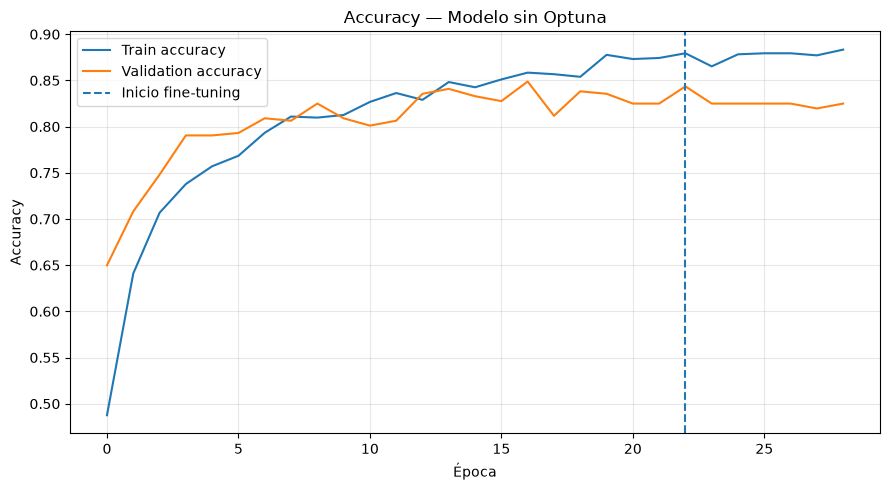

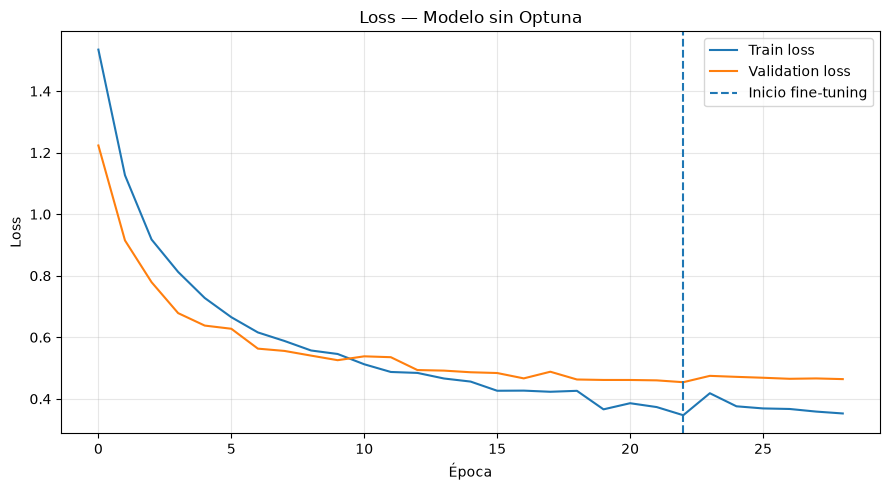

In [24]:
# 22. Curvas de entrenamiento: modelo sin Optuna

def unir_historiales(history_fase1, history_fase2):
    resultado = {}

    for metrica in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        resultado[metrica] = history_fase1[metrica] + history_fase2[metrica]

    resultado["inicio_fine_tuning"] = len(history_fase1["accuracy"])

    return resultado


def graficar_curvas(hist, titulo_sufijo, archivo=None):
    for metrica, etiqueta in [("accuracy", "Accuracy"), ("loss", "Loss")]:
        plt.figure(figsize=(9, 5))
        plt.plot(hist[metrica], label=f"Train {metrica}")
        plt.plot(hist[f"val_{metrica}"], label=f"Validation {metrica}")
        plt.axvline(
            hist["inicio_fine_tuning"] - 1,
            linestyle="--",
            label="Inicio fine-tuning"
        )
        plt.title(f"{etiqueta} — {titulo_sufijo}")
        plt.xlabel("Época")
        plt.ylabel(etiqueta)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()

        if archivo:
            plt.savefig(
                os.path.join(RESULTS_DIR, f"{archivo}_{metrica}.png"),
                dpi=120
            )

        plt.show()


hist_base = unir_historiales(history_base_fase1, history_base_fase2)

graficar_curvas(hist_base, "Modelo sin Optuna", "mnv3_curvas_sin_optuna")

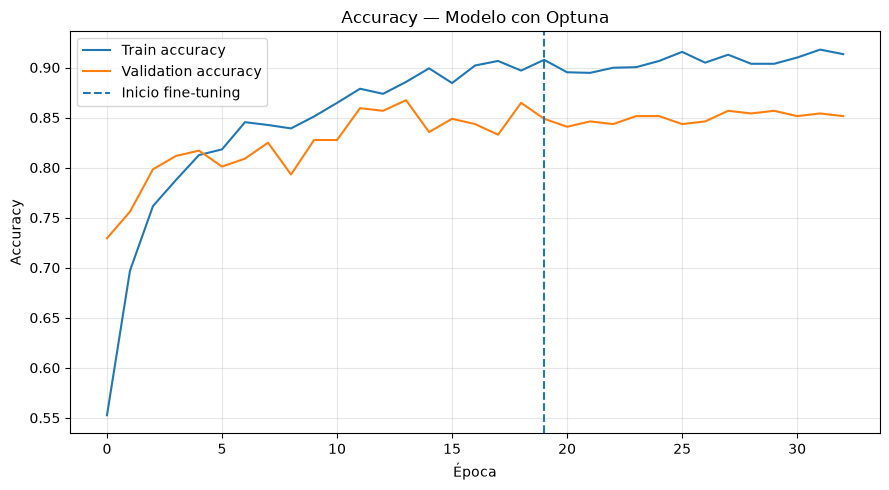

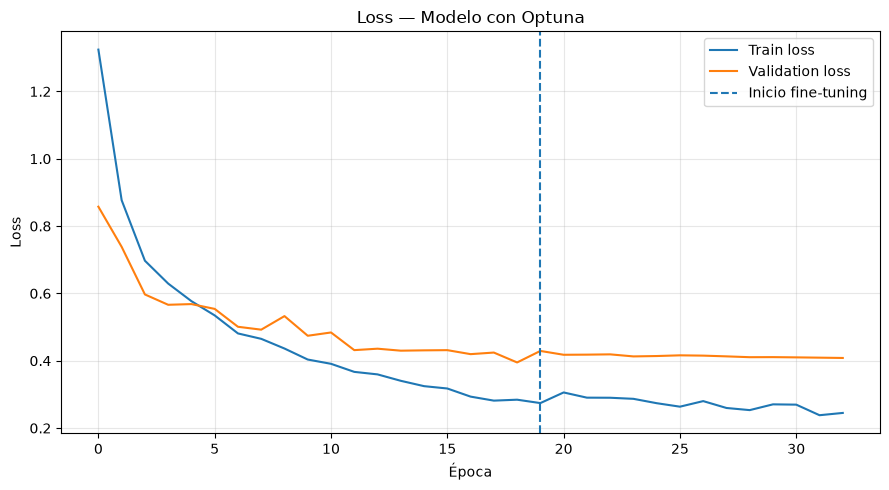

In [25]:
# 23. Curvas de entrenamiento: modelo con Optuna

hist_optuna = unir_historiales(history_optuna_fase1, history_optuna_fase2)

graficar_curvas(hist_optuna, "Modelo con Optuna", "mnv3_curvas_optuna")

In [26]:
# 24. Reportes de clasificación

print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — SIN OPTUNA")
print("=" * 70)
print(classification_report(y_true, y_pred_base, CLASSES, digits=4))

print()
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — CON OPTUNA")
print("=" * 70)
print(classification_report(y_true, y_pred_optuna, CLASSES, digits=4))

REPORTE DE CLASIFICACIÓN — SIN OPTUNA
              precision      recall    f1-score     support

  cardboard      0.9167      0.9016      0.9091          61
      glass      0.8143      0.7500      0.7808          76
      metal      0.8095      0.8226      0.8160          62
      paper      0.8721      0.8333      0.8523          90
    plastic      0.7838      0.7945      0.7891          73
      trash      0.6129      0.8636      0.7170          22

   accuracy                              0.8203         384
  macro avg      0.8015      0.8276      0.8107         384
weighted avg      0.8260      0.8203      0.8215         384

REPORTE DE CLASIFICACIÓN — CON OPTUNA
              precision      recall    f1-score     support

  cardboard      0.9298      0.8689      0.8983          61
      glass      0.8378      0.8158      0.8267          76
      metal      0.8438      0.8710      0.8571          62
      paper      0.8539      0.8444      0.8492          90
    plastic      0.

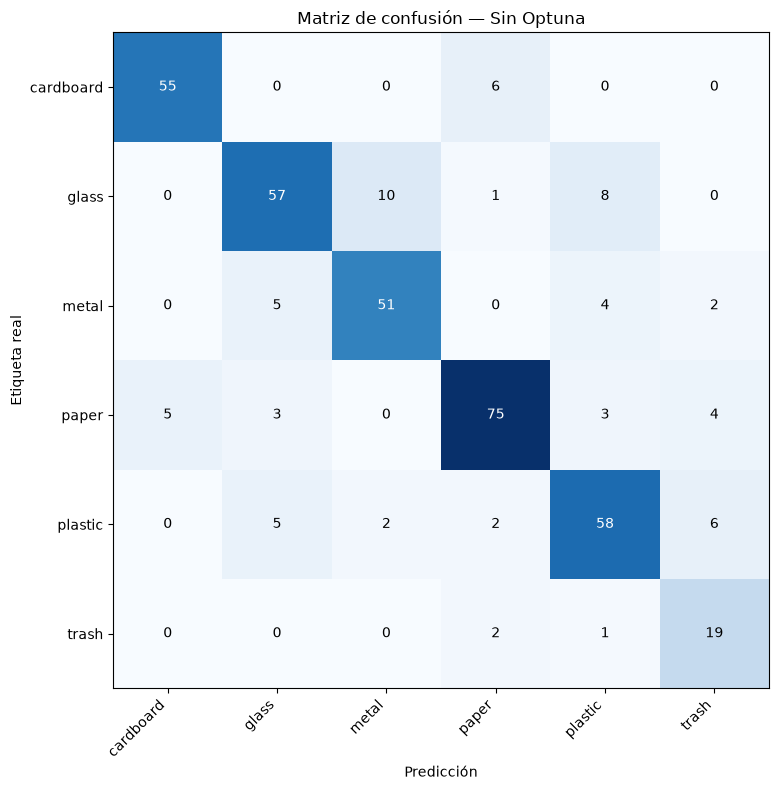

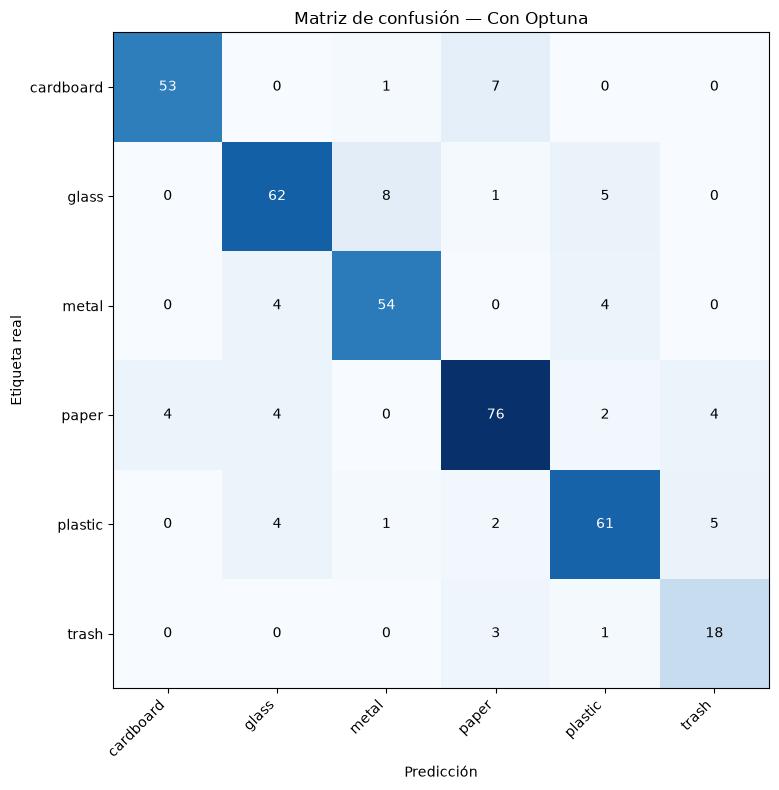

In [27]:
# 25. Matrices de confusión

cm_base = confusion_matrix(y_true, y_pred_base)
cm_optuna = confusion_matrix(y_true, y_pred_optuna)


def graficar_matriz_confusion(cm, titulo, archivo=None):
    fig, ax = plt.subplots(figsize=(9, 8))
    imagen = ax.imshow(cm, interpolation="nearest", cmap="Blues")

    ax.set_xticks(np.arange(N_CLASSES))
    ax.set_yticks(np.arange(N_CLASSES))
    ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")

    umbral = cm.max() / 2.0
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(
                j, i, f"{cm[i, j]:d}",
                ha="center", va="center",
                color="white" if cm[i, j] > umbral else "black"
            )

    plt.title(titulo)
    plt.tight_layout()

    if archivo:
        plt.savefig(os.path.join(RESULTS_DIR, archivo), dpi=120)

    plt.show()


graficar_matriz_confusion(
    cm_base,
    "Matriz de confusión — Sin Optuna",
    "mnv3_matriz_confusion_sin_optuna.png"
)

graficar_matriz_confusion(
    cm_optuna,
    "Matriz de confusión — Con Optuna",
    "mnv3_matriz_confusion_optuna.png"
)

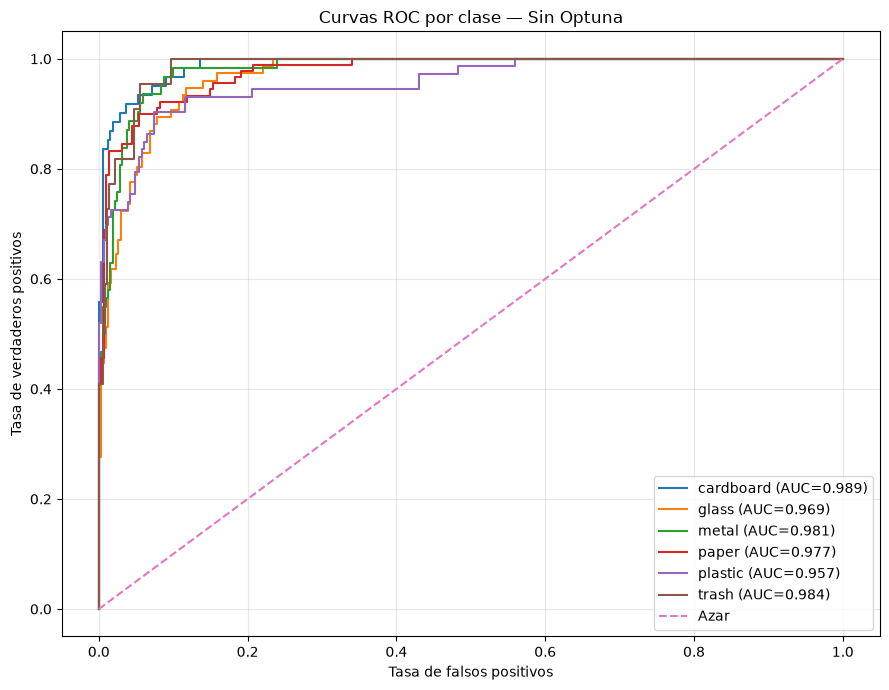

In [28]:
# 26. Curvas ROC por clase — Sin Optuna

y_true_bin = label_binarize(y_true, N_CLASSES)


def graficar_roc_por_clase(y_bin, y_prob, titulo, archivo=None):
    plt.figure(figsize=(9, 7))

    aucs = {}

    for i, clase in enumerate(CLASSES):
        fpr, tpr, roc_auc = roc_curve(y_bin[:, i], y_prob[:, i])
        aucs[clase] = roc_auc

        plt.plot(fpr, tpr, label=f"{clase} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title(titulo)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if archivo:
        plt.savefig(os.path.join(RESULTS_DIR, archivo), dpi=120)

    plt.show()

    return aucs


auc_clases_base = graficar_roc_por_clase(
    y_true_bin,
    y_prob_base,
    "Curvas ROC por clase — Sin Optuna",
    "mnv3_roc_sin_optuna.png"
)

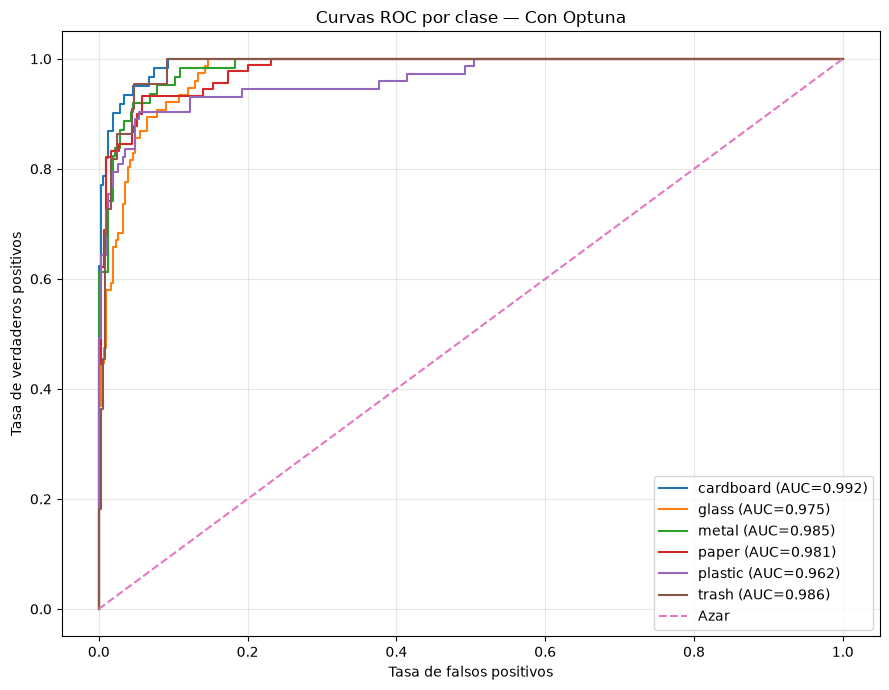

In [29]:
# 27. Curvas ROC por clase — Con Optuna

auc_clases_optuna = graficar_roc_por_clase(
    y_true_bin,
    y_prob_optuna,
    "Curvas ROC por clase — Con Optuna",
    "mnv3_roc_optuna.png"
)

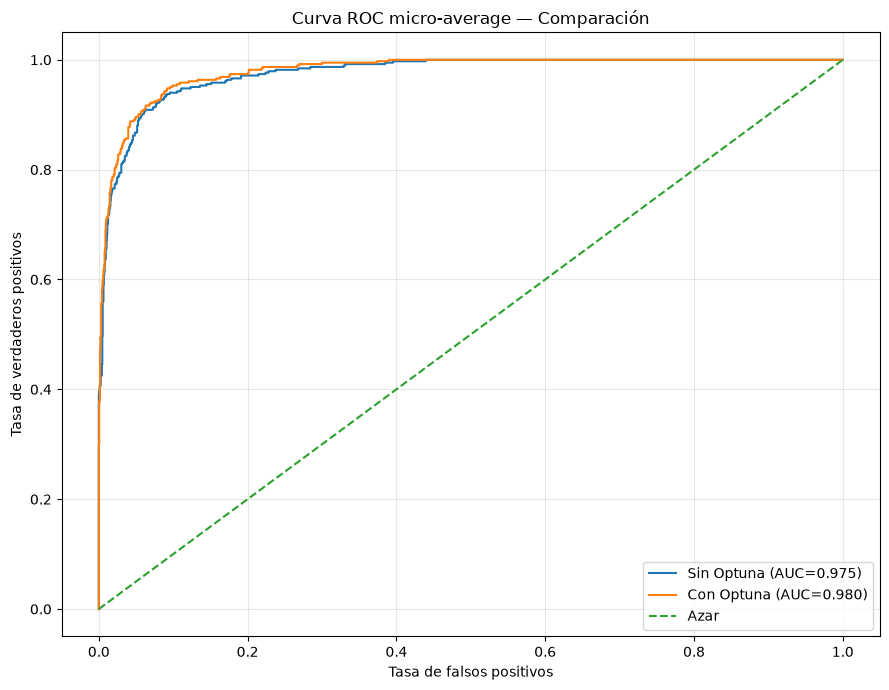

In [30]:
# 28. Comparación ROC micro-average

fpr_base_micro, tpr_base_micro, auc_base_micro = roc_curve(
    y_true_bin.ravel(),
    y_prob_base.ravel()
)

fpr_optuna_micro, tpr_optuna_micro, auc_optuna_micro = roc_curve(
    y_true_bin.ravel(),
    y_prob_optuna.ravel()
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_base_micro,
    tpr_base_micro,
    label=f"Sin Optuna (AUC={auc_base_micro:.3f})"
)

plt.plot(
    fpr_optuna_micro,
    tpr_optuna_micro,
    label=f"Con Optuna (AUC={auc_optuna_micro:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC micro-average — Comparación")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "mnv3_roc_micro_comparacion.png"), dpi=120)
plt.show()

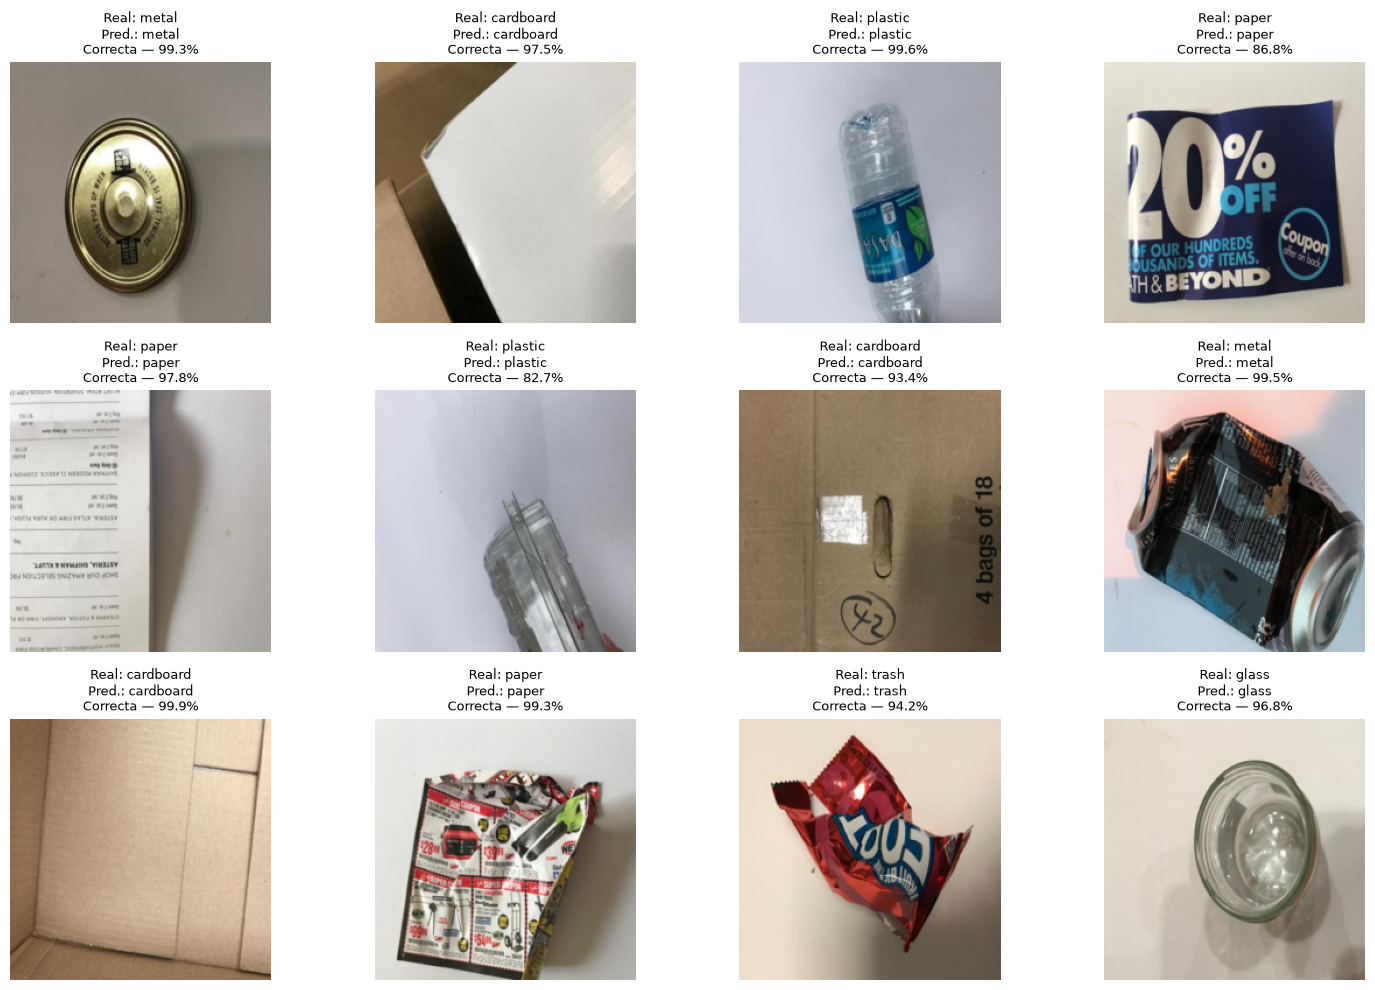

In [31]:
# 29. Predicciones aleatorias del modelo con Optuna

# Dataset paralelo sin normalizar, solo para mostrar las imágenes. Comparte el mismo
# orden que test_ds, así que los índices sirven para los dos.
test_ds_vis = datasets.ImageFolder(
    TEST_DIR,
    transform=transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor()
    ])
)

rng = np.random.default_rng(SEED)
indices = rng.choice(
    len(test_ds),
    size=min(12, len(test_ds)),
    replace=False
)

lote = torch.stack([test_ds[i][0] for i in indices]).to(DEVICE)

model_optuna.eval()
with torch.no_grad():
    selected_prob = torch.softmax(model_optuna(lote), dim=1).cpu().numpy()

plt.figure(figsize=(15, 10))

for posicion, indice in enumerate(indices):
    imagen, true_index = test_ds_vis[indice]
    pred_index = int(np.argmax(selected_prob[posicion]))
    confidence = float(selected_prob[posicion][pred_index])

    plt.subplot(3, 4, posicion + 1)
    plt.imshow(imagen.permute(1, 2, 0).numpy())

    estado = "Correcta" if true_index == pred_index else "Incorrecta"

    plt.title(
        f"Real: {CLASSES[true_index]}\n"
        f"Pred.: {CLASSES[pred_index]}\n"
        f"{estado} — {confidence:.1%}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "mnv3_predicciones_optuna.png"), dpi=120)
plt.show()

In [32]:
# 30. Resumen final imprimible

print("=" * 76)
print("RESUMEN FINAL — TRASHNET MOBILENETV3SMALL (PYTORCH)")
print("=" * 76)

print("\nDATASET")
print(f"- Train: {sum(train_count.values())} imágenes")
print(f"- Validation: {sum(valid_count.values())} imágenes")
print(f"- Test: {sum(test_count.values())} imágenes")
print(f"- Clases: {N_CLASSES}")
print(f"- Tamaño de entrada: {IMG_SIZE}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Dispositivo: {DEVICE}")

print("\nMODELO SIN OPTUNA")
print(f"- Dense units: {BASE_DENSE_UNITS}")
print(f"- Dropout: {BASE_DROPOUT}")
print(f"- Learning rate fase 1: {BASE_LR}")
print(f"- Optimizador: {BASE_OPTIMIZER}")
print(f"- Accuracy test: {metricas_base['Accuracy']:.2%}")
print(f"- Precision macro: {metricas_base['Precision macro']:.2%}")
print(f"- Recall macro: {metricas_base['Recall macro']:.2%}")
print(f"- F1 macro: {metricas_base['F1 macro']:.2%}")
print(f"- ROC AUC macro OVR: {metricas_base['ROC AUC macro OVR']:.4f}")

print("\nMODELO CON OPTUNA")
print(f"- Trials: {OPTUNA_TRIALS}")
print(f"- Mejor trial: {study.best_trial.number}")
print(f"- Dense units: {BEST_DENSE_UNITS}")
print(f"- Dropout: {BEST_DROPOUT}")
print(f"- Learning rate fase 1: {BEST_LR:.8f}")
print(f"- Optimizador: {BEST_OPTIMIZER}")
print(f"- Accuracy test: {metricas_optuna['Accuracy']:.2%}")
print(f"- Precision macro: {metricas_optuna['Precision macro']:.2%}")
print(f"- Recall macro: {metricas_optuna['Recall macro']:.2%}")
print(f"- F1 macro: {metricas_optuna['F1 macro']:.2%}")
print(f"- ROC AUC macro OVR: {metricas_optuna['ROC AUC macro OVR']:.4f}")

print("\nCOMPARACIÓN")
print(f"- Diferencia de accuracy: {diferencia:+.2%}")
print(f"- AUC micro sin Optuna: {auc_base_micro:.4f}")
print(f"- AUC micro con Optuna: {auc_optuna_micro:.4f}")

mejor_modelo = (
    "Con Optuna"
    if metricas_optuna["Accuracy"] > metricas_base["Accuracy"]
    else "Sin Optuna"
    if metricas_optuna["Accuracy"] < metricas_base["Accuracy"]
    else "Empate"
)

print(f"- Mejor accuracy en test: {mejor_modelo}")

print("\nARCHIVOS")
print(f"- Modelo sin Optuna: {RUTA_MODELO_BASE}")
print(f"- Modelo con Optuna: {RUTA_MODELO_OPTUNA}")
print(f"- Figuras: {RESULTS_DIR}/mnv3_*.png")
print("=" * 76)

RESUMEN FINAL — TRASHNET MOBILENETV3SMALL (PYTORCH)

DATASET
- Train: 1766 imágenes
- Validation: 377 imágenes
- Test: 384 imágenes
- Clases: 6
- Tamaño de entrada: (224, 224)
- Batch size: 32
- Dispositivo: cpu

MODELO SIN OPTUNA
- Dense units: 128
- Dropout: 0.35
- Learning rate fase 1: 0.0003
- Optimizador: adam
- Accuracy test: 82.03%
- Precision macro: 80.15%
- Recall macro: 82.76%
- F1 macro: 81.07%
- ROC AUC macro OVR: 0.9761

MODELO CON OPTUNA
- Trials: 10
- Mejor trial: 1
- Dense units: 64
- Dropout: 0.2
- Learning rate fase 1: 0.00087060
- Optimizador: adam
- Accuracy test: 84.38%
- Precision macro: 82.79%
- Recall macro: 84.23%
- F1 macro: 83.36%
- ROC AUC macro OVR: 0.9802

COMPARACIÓN
- Diferencia de accuracy: +2.34%
- AUC micro sin Optuna: 0.9754
- AUC micro con Optuna: 0.9797
- Mejor accuracy en test: Con Optuna

ARCHIVOS
- Modelo sin Optuna: modelos/trashnet_mobilenetv3_sin_optuna.pt
- Modelo con Optuna: modelos/trashnet_mobilenetv3_optuna.pt
- Figuras: predicciones/mnv